In [ ]:

!pip install numpy pandas matplotlib seaborn psycopg2-binary sqlalchemy


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from psycopg2.extensions import ISOLATION_LEVEL_AUTOCOMMIT
from datetime import datetime
from sqlalchemy import create_engine


In [ ]:
df=pd.read_csv(r'C:\Users\katlee\nithi\.venv\ICRISAT-District Level Data - ICRISAT-District Level Data.csv')
df

In [11]:
df.describe()

,Dist Code,Year,State Code,RICE AREA (1000 ha),RICE PRODUCTION (1000 tons),RICE YIELD (Kg per ha),WHEAT AREA (1000 ha),WHEAT PRODUCTION (1000 tons),WHEAT YIELD (Kg per ha),KHARIF SORGHUM AREA (1000 ha),...,SUGARCANE YIELD (Kg per ha),COTTON AREA (1000 ha),COTTON PRODUCTION (1000 tons),COTTON YIELD (Kg per ha),FRUITS AREA (1000 ha),VEGETABLES AREA (1000 ha),FRUITS AND VEGETABLES AREA (1000 ha),POTATOES AREA (1000 ha),ONION AREA (1000 ha),FODDER AREA (1000 ha)
count,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,...,16146.00000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000,16146.000000
mean,269.769231,1991.496841,9.568562,128.593192,224.889565,1486.924784,77.057946,182.012746,1492.419859,22.632268,...,4500.15306,28.018367,7.229225,124.644823,7.750478,11.086250,18.677877,3.177038,1.194604,21.550328
std,278.309125,15.011185,4.988538,160.078825,326.629828,956.185281,100.394479,348.834254,1081.255367,45.062714,...,3153.97042,74.239648,25.042132,207.681147,13.591135,18.003257,25.881842,8.029509,4.285067,60.062601
min,1.000000,1966.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.00000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,78.000000,1978.000000,6.000000,10.400000,9.460000,800.000000,1.770000,2.000000,750.000000,0.000000,...,2000.00000,0.000000,0.000000,0.000000,0.310000,1.600000,2.520000,0.000000,0.060000,0.000000
50%,156.000000,1991.000000,10.000000,66.800000,95.840000,1333.210000,36.800000,42.700000,1347.450000,2.050000,...,4502.21000,0.050000,0.000000,0.000000,2.220000,4.740000,8.945000,0.390000,0.280000,1.200000
75%,241.000000,2005.000000,12.000000,191.390000,315.715000,2113.517500,123.000000,215.192500,2131.580000,20.900000,...,6704.60500,10.097500,2.000000,202.270000,8.790000,12.510000,23.570000,3.150000,0.880000,16.762500
max,917.000000,2017.000000,20.000000,1154.230000,3215.010000,5653.830000,879.490000,4305.500000,5541.520000,334.800000,...,22062.30000,800.890000,376.610000,5000.000000,159.540000,200.060000,240.990000,111.610000,131.350000,1162.660000


In [12]:
df.shape

(16146, 80)

In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16146 entries, 0 to 16145
Data columns (total 80 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Dist Code                                    16146 non-null  int64  
 1   Year                                         16146 non-null  int64  
 2   State Code                                   16146 non-null  int64  
 3   State Name                                   16146 non-null  object 
 4   Dist Name                                    16146 non-null  object 
 5   RICE AREA (1000 ha)                          16146 non-null  float64
 6   RICE PRODUCTION (1000 tons)                  16146 non-null  float64
 7   RICE YIELD (Kg per ha)                       16146 non-null  float64
 8   WHEAT AREA (1000 ha)                         16146 non-null  float64
 9   WHEAT PRODUCTION (1000 tons)                 16146 non-null  float64
 10

Dist Code                               0
Year                                    0
State Code                              0
State Name                              0
Dist Name                               0
                                       ..
VEGETABLES AREA (1000 ha)               0
FRUITS AND VEGETABLES AREA (1000 ha)    0
POTATOES AREA (1000 ha)                 0
ONION AREA (1000 ha)                    0
FODDER AREA (1000 ha)                   0
Length: 80, dtype: int64

In [16]:
# Function to standardize the column names
def standardize_column_names(df):
    new_cols = {}
    for col in df.columns:
        # Standardize Geographical and Year columns
        if col in ['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name']:
            new_name = col.lower().replace(' ', '_')
        else:
            # 1. Remove units in parentheses and standardize metric abbreviations
            # Note: The .lower() converts 'Kg per ha' to 'kg per ha' for consistency
            new_name = col.lower().replace(' (1000 ha)', '_1000_ha')
            new_name = new_name.replace(' (1000 tons)', '_1000_tons')
            new_name = new_name.replace(' (kg per ha)', '_kg_ha') # Yield
            
            # 2. Further cleaning (replace 'and' and spaces)
            new_name = new_name.replace(' and ', '_and_')
            new_name = new_name.replace(' ', '_')
            new_name = new_name.replace('(', '').replace(')', '')
        
        new_cols[col] = new_name
    
    # Rename the columns in the DataFrame
    df.rename(columns=new_cols, inplace=True)
    return df

# Apply the renaming and save the new file
df = standardize_column_names(df)
rename_file_name = "ICRISAT_District_Level_clean.csv"
df.to_csv(rename_file_name,index= False)

In [17]:
print(df.columns)

Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name',
       'rice_area_1000_ha', 'rice_production_1000_tons', 'rice_yield_kg_ha',
       'wheat_area_1000_ha', 'wheat_production_1000_tons', 'wheat_yield_kg_ha',
       'kharif_sorghum_area_1000_ha', 'kharif_sorghum_production_1000_tons',
       'kharif_sorghum_yield_kg_ha', 'rabi_sorghum_area_1000_ha',
       'rabi_sorghum_production_1000_tons', 'rabi_sorghum_yield_kg_ha',
       'sorghum_area_1000_ha', 'sorghum_production_1000_tons',
       'sorghum_yield_kg_ha', 'pearl_millet_area_1000_ha',
       'pearl_millet_production_1000_tons', 'pearl_millet_yield_kg_ha',
       'maize_area_1000_ha', 'maize_production_1000_tons', 'maize_yield_kg_ha',
       'finger_millet_area_1000_ha', 'finger_millet_production_1000_tons',
       'finger_millet_yield_kg_ha', 'barley_area_1000_ha',
       'barley_production_1000_tons', 'barley_yield_kg_ha',
       'chickpea_area_1000_ha', 'chickpea_production_1000_tons',
       'chickpea_yield_kg_

In [18]:
print(df.columns)

Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name',
       'rice_area_1000_ha', 'rice_production_1000_tons', 'rice_yield_kg_ha',
       'wheat_area_1000_ha', 'wheat_production_1000_tons', 'wheat_yield_kg_ha',
       'kharif_sorghum_area_1000_ha', 'kharif_sorghum_production_1000_tons',
       'kharif_sorghum_yield_kg_ha', 'rabi_sorghum_area_1000_ha',
       'rabi_sorghum_production_1000_tons', 'rabi_sorghum_yield_kg_ha',
       'sorghum_area_1000_ha', 'sorghum_production_1000_tons',
       'sorghum_yield_kg_ha', 'pearl_millet_area_1000_ha',
       'pearl_millet_production_1000_tons', 'pearl_millet_yield_kg_ha',
       'maize_area_1000_ha', 'maize_production_1000_tons', 'maize_yield_kg_ha',
       'finger_millet_area_1000_ha', 'finger_millet_production_1000_tons',
       'finger_millet_yield_kg_ha', 'barley_area_1000_ha',
       'barley_production_1000_tons', 'barley_yield_kg_ha',
       'chickpea_area_1000_ha', 'chickpea_production_1000_tons',
       'chickpea_yield_kg_

In [19]:
df.replace(-1, np.nan, inplace=True)   # replace with NaN
df.dropna(inplace=True)                # drop missing rows
df.fillna(0, inplace=True) 

In [20]:
df.isna().sum()

dist_code                             0
year                                  0
state_code                            0
state_name                            0
dist_name                             0
                                     ..
vegetables_area_1000_ha               0
fruits_and_vegetables_area_1000_ha    0
potatoes_area_1000_ha                 0
onion_area_1000_ha                    0
fodder_area_1000_ha                   0
Length: 80, dtype: int64

In [21]:
import re
import numpy as np
import pandas as pd
from IPython.display import display

# --- 0) Clean sentinel values first ---
df = df.replace(-1, np.nan)

# --- 1) First: detect ORIGINAL 1000-unit columns and rename ONLY the headers ---

area_1000_cols_raw = [c for c in df.columns if c.endswith('_area_1000_ha')]
prod_1000_cols_raw = [c for c in df.columns if c.endswith('_production_1000_tons')]

rename_map = {}
rename_map.update({c: c.replace('_area_1000_ha', '_area_ha') for c in area_1000_cols_raw})
rename_map.update({c: c.replace('_production_1000_tons', '_production_tons') for c in prod_1000_cols_raw})

df = df.rename(columns=rename_map)

# NOTE: values still represent 1000 ha / 1000 tons.
# Only the NAMES changed to *_area_ha and *_production_tons.

# --- 2) Identify columns by (new) names ---
area_cols  = [c for c in df.columns if re.search(r'_area_ha$', c)]
prod_cols  = [c for c in df.columns if re.search(r'_production_tons$', c)]
yield_cols = [c for c in df.columns if re.search(r'_yield_kg_ha$', c)]

# --- 3) Convert to numeric (safe) ---
for cols in (area_cols, prod_cols, yield_cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# --- 4) Yield consistency check WITHOUT changing values ---

# IMPORTANT:
#   area_col values  = A_1000 (still 1000 ha, even though called *_area_ha)
#   prod_col values  = P_1000 (still 1000 tons, even though called *_production_tons)
#
# Real area (ha)      = A_1000 * 1000
# Real production (t) = P_1000 * 1000
# Yield (kg/ha)       = (P_1000 * 1000 * 1000) / (A_1000 * 1000)
#                     = (P_1000 * 1000) / A_1000

def find_pairs(prefixes):
    pairs = []
    for p in prefixes:
        a = f"{p}_area_ha"
        pr = f"{p}_production_tons"
        y = f"{p}_yield_kg_ha"
        if a in df.columns and pr in df.columns:
            pairs.append((p, a, pr, y if y in df.columns else None))
    return pairs

prefixes = set()
for c in df.columns:
    m = re.match(r'(.+?)_(area_ha|production_tons|yield_kg_ha)$', c)
    if m:
        prefixes.add(m.group(1))

pairs = find_pairs(prefixes)

for p, a, pr, y in pairs:
    denom = df[a]   # A_1000
    df[f"{p}_yield_computed_kg_ha"] = (df[pr] * 1000) / denom.replace(0, np.nan)
    if y:
        diff = (df[f"{p}_yield_computed_kg_ha"] - df[y]).abs()
        rel  = diff / df[y].replace(0, np.nan)
        df[f"{p}_yield_diff_kg_ha"] = diff
        df[f"{p}_yield_rel_error"]  = rel

# --- 5) Simple outlier flags for yields ---
LOW_KG_HA, HIGH_KG_HA = 100, 20000

for ycol in yield_cols:
    flag = ycol.replace('_yield_kg_ha', '_yield_flag')
    df[flag] = np.where(
        (df[ycol].notna()) & ((df[ycol] < LOW_KG_HA) | (df[ycol] > HIGH_KG_HA)),
        'outlier', 'ok'
    )

# --- 6) Quick audit printout ---
summary = []
for p, a, pr, y in pairs:
    cols = [c for c in [
        a, pr, y,
        f"{p}_yield_computed_kg_ha",
        f"{p}_yield_diff_kg_ha",
        f"{p}_yield_rel_error"
    ] if c in df.columns]
    s = df[cols].describe(percentiles=[0.25, 0.5, 0.75]).T
    s['missing']     = df[cols].isna().sum()
    s['non_missing'] = df[cols].notna().sum()
    s['prefix']      = p
    summary.append(s)

audit = pd.concat(summary, axis=0) if summary else pd.DataFrame()

print("NO value conversion applied.")
print("Columns renamed to *_area_ha and *_production_tons,")
print("but values are still in 1000 ha and 1000 tons.\n")

print("Sample columns:")
print([c for c in df.columns if re.search(r'_(area_ha|production_tons|yield_kg_ha)$', c)][:20])

display(audit.head(30))

C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\3896259381.py:69: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{p}_yield_rel_error"]  = rel
C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\3896259381.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{p}_yield_computed_kg_ha"] = (df[pr] * 1000) / denom.replace(0, np.nan)
C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\3896259381.py:68: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which 

NO value conversion applied.
Columns renamed to *_area_ha and *_production_tons,
but values are still in 1000 ha and 1000 tons.

Sample columns:
['rice_area_ha', 'rice_production_tons', 'rice_yield_kg_ha', 'wheat_area_ha', 'wheat_production_tons', 'wheat_yield_kg_ha', 'kharif_sorghum_area_ha', 'kharif_sorghum_production_tons', 'kharif_sorghum_yield_kg_ha', 'rabi_sorghum_area_ha', 'rabi_sorghum_production_tons', 'rabi_sorghum_yield_kg_ha', 'sorghum_area_ha', 'sorghum_production_tons', 'sorghum_yield_kg_ha', 'pearl_millet_area_ha', 'pearl_millet_production_tons', 'pearl_millet_yield_kg_ha', 'maize_area_ha', 'maize_production_tons']


,count,mean,std,min,25%,50%,75%,max,missing,non_missing,prefix
finger_millet_area_ha,13092.0,6.689385,23.732925,0.0,0.000000e+00,0.000000e+00,6.600000e-01,261.000000,0,13092,finger_millet
finger_millet_production_tons,13092.0,8.006594,31.815759,0.0,0.000000e+00,0.000000e+00,4.300000e-01,459.980000,0,13092,finger_millet
finger_millet_yield_kg_ha,13092.0,354.969995,589.686764,0.0,0.000000e+00,0.000000e+00,7.129675e+02,4440.000000,0,13092,finger_millet
finger_millet_yield_computed_kg_ha,4607.0,1003.976654,575.284481,0.0,6.596483e+02,9.605917e+02,1.322457e+03,4400.000000,8485,4607,finger_millet
finger_millet_yield_diff_kg_ha,4607.0,2.178982,27.719263,0.0,4.263256e-14,2.114759e-03,3.605881e-03,1000.000000,8485,4607,finger_millet
finger_millet_yield_rel_error,4430.0,0.002479,0.033119,0.0,2.557379e-07,2.141124e-06,4.444425e-06,1.000000,8662,4430,finger_millet
barley_area_ha,13092.0,3.182541,8.341773,0.0,0.000000e+00,0.000000e+00,2.370000e+00,137.700000,0,13092,barley
barley_production_tons,13092.0,5.306999,15.802878,0.0,0.000000e+00,0.000000e+00,3.430000e+00,361.590000,0,13092,barley
barley_yield_kg_ha,13092.0,780.070128,990.063882,0.0,0.000000e+00,0.000000e+00,1.383312e+03,7119.970000,0,13092,barley
barley_yield_computed_kg_ha,6278.0,1623.000116,818.540108,0.0,1.000000e+03,1.416667e+03,2.052786e+03,7142.857143,6814,6278,barley


In [22]:
# ✅ Save cleaned dataset
output_path = "final_cleaned_agriculture_data.csv"
df.to_csv(output_path, index=False)

print(f"✅ Cleaned dataset saved successfully as: {output_path}")

✅ Cleaned dataset saved successfully as: final_cleaned_agriculture_data.csv


EDA

C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\2934407888.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state_name', y='rice_production_tons', data=top_rice_states, palette='viridis')


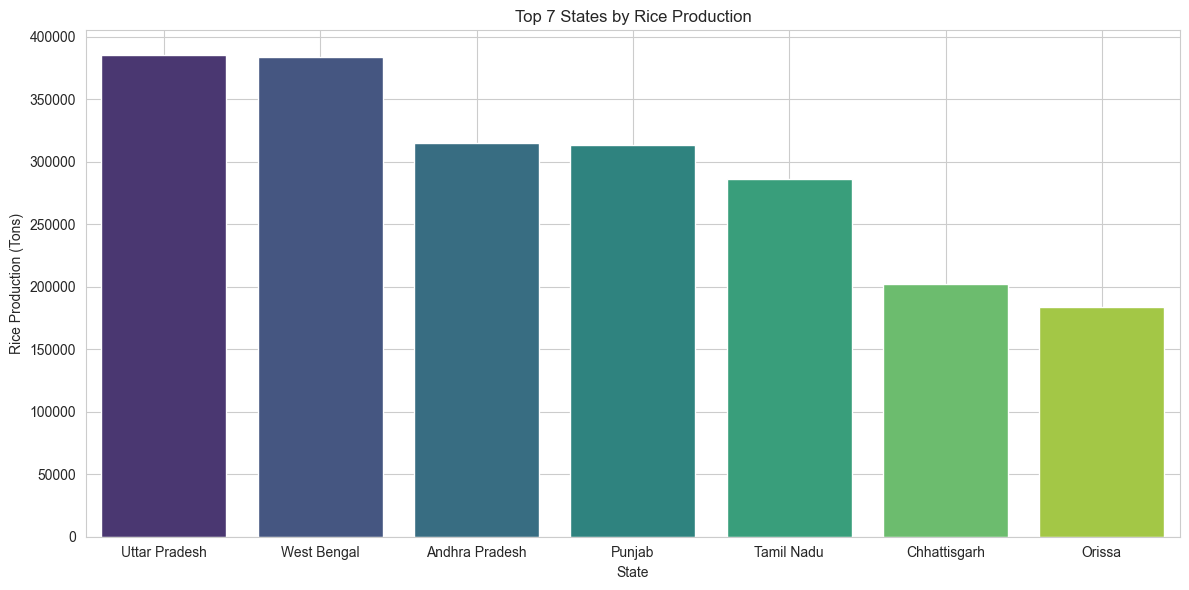

In [24]:
#EDA Visualization
sns.set_style("whitegrid")
# Create a bar plot for Rice Production by State
#Top 7 RICE PRODUCTION State Data(Bar_plot)
plt.figure(figsize=(12, 6))
top_rice_states = df.groupby('state_name')['rice_production_tons'].sum().nlargest(7).reset_index()
sns.barplot(x='state_name', y='rice_production_tons', data=top_rice_states, palette='viridis')
plt.xticks(rotation=360)
plt.grid(axis='x')
plt.title('Top 7 States by Rice Production')
plt.xlabel('State')
plt.ylabel('Rice Production (Tons)')
plt.tight_layout()

plt.show()

C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\3253401527.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


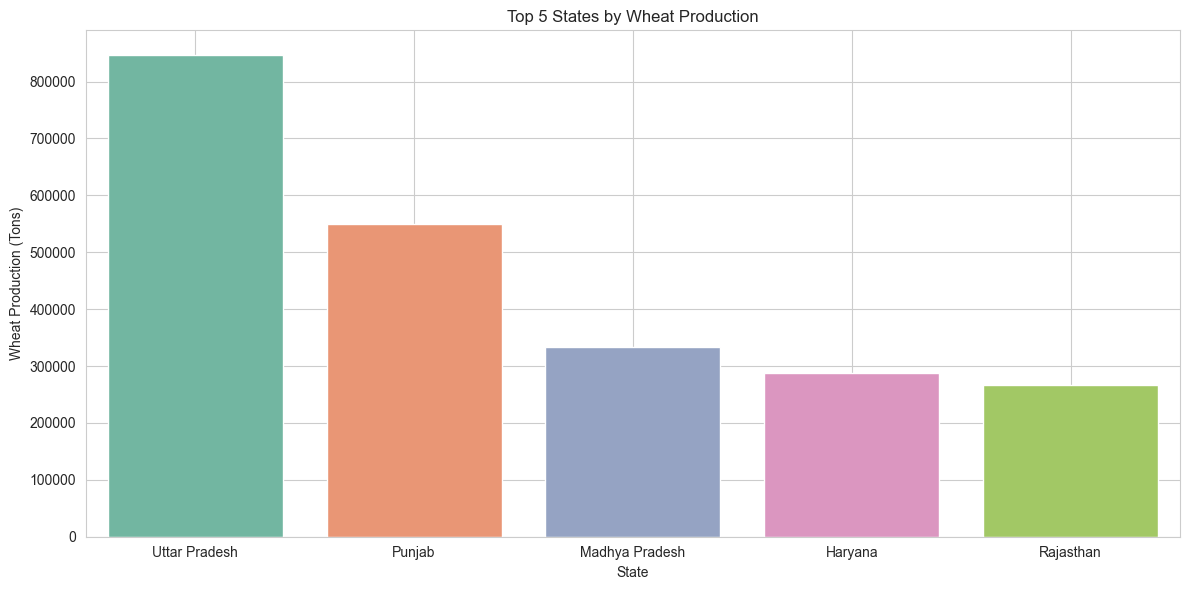

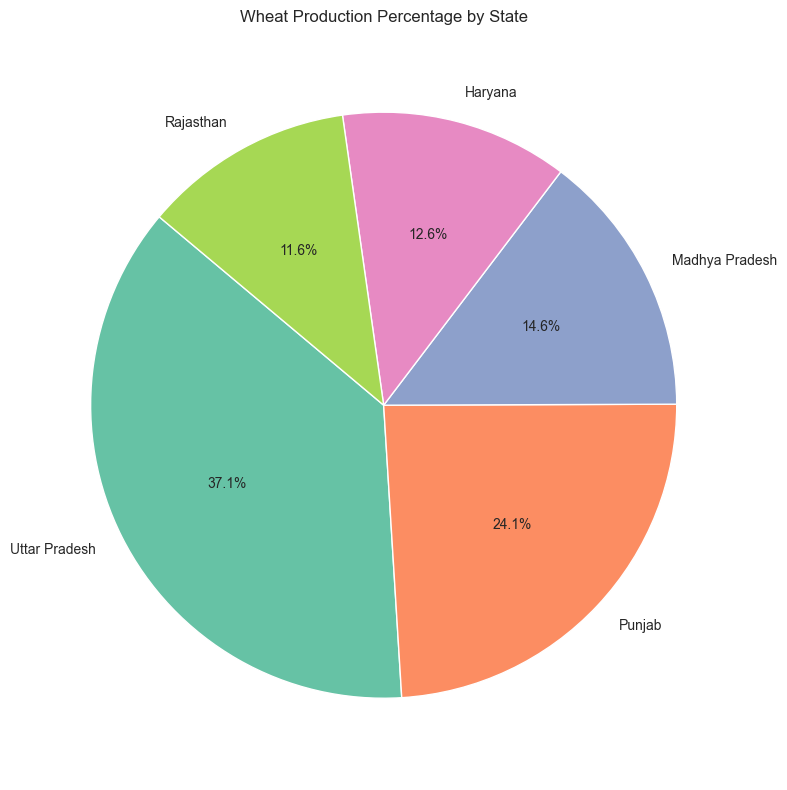

In [28]:
# Top 5 Wheat Producing States Data (Bar chart) and its percentage (%) (Pie chart)
plt.figure(figsize=(12, 6))

top_wheat_states = df.groupby('state_name')['wheat_production_tons'] \
                     .sum().nlargest(5).reset_index()

sns.barplot(
    x='state_name',
    y='wheat_production_tons',
    data=top_wheat_states,
    palette='Set2'   # ✅ Attractive pastel colors
)

plt.xticks(rotation=360)
plt.grid(axis='x')
plt.title('Top 5 States by Wheat Production')
plt.xlabel('State')
plt.ylabel('Wheat Production (Tons)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 8))
# Top 5 Wheat Producing States Data (Bar chart) and its percentage (%) (Pie chart)
colors = sns.color_palette('Set2', n_colors=len(top_wheat_states))

plt.pie(
    top_wheat_states['wheat_production_tons'],
    labels=top_wheat_states['state_name'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors
)

plt.title('Wheat Production Percentage by State')
plt.axis('equal')
plt.tight_layout()
plt.show()


C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\3603211521.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


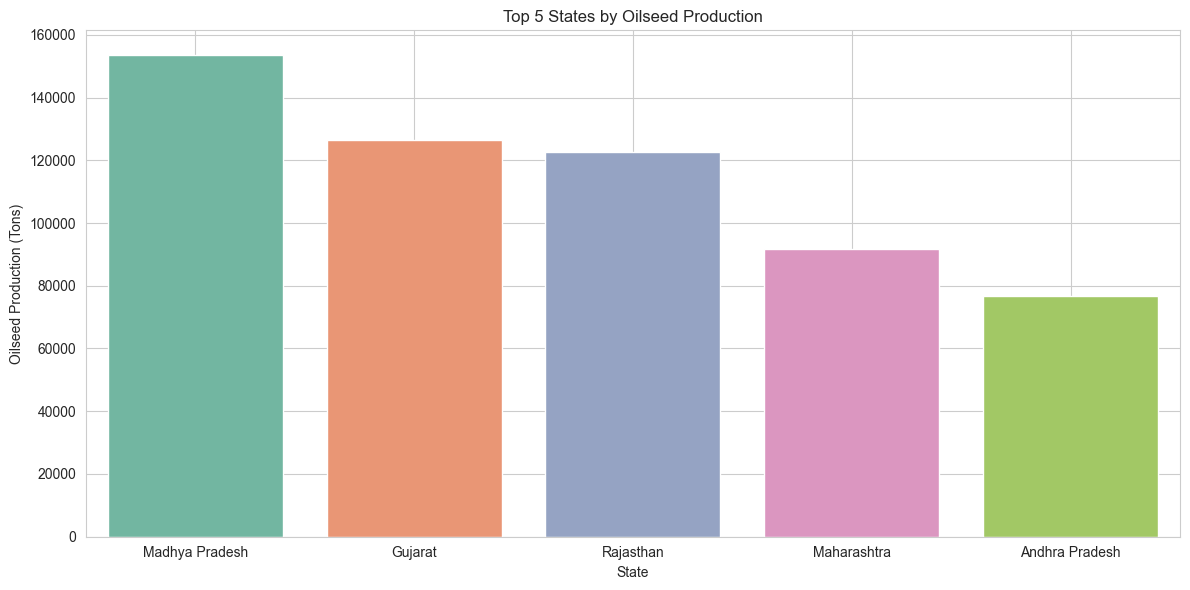

In [30]:
# Oil seed production by top 5 states
plt.figure(figsize=(12, 6))

top_oilseed_states = df.groupby('state_name')['oilseeds_production_tons'] \
                       .sum().nlargest(5).reset_index()

sns.barplot(
    x='state_name',
    y='oilseeds_production_tons',
    data=top_oilseed_states,
    palette='Set2'  
)

plt.xticks(rotation=360)
plt.grid(axis='x')
plt.title('Top 5 States by Oilseed Production')
plt.xlabel('State')
plt.ylabel('Oilseed Production (Tons)')
plt.tight_layout()

plt.show()


C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\2740129750.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state_name', y='sunflower_production_tons', data=top_sunflower_states, palette='viridis')


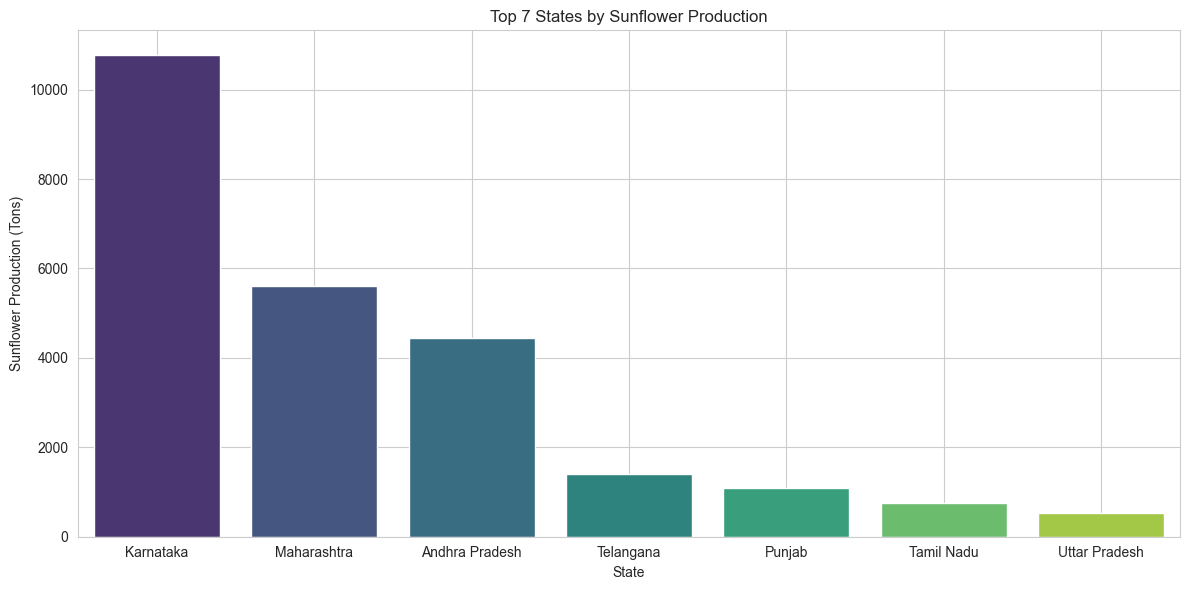

In [32]:
#Top 7 SUNFLOWER PRODUCTION  State

plt.figure(figsize=(12, 6))
top_sunflower_states = df.groupby('state_name')['sunflower_production_tons'].sum().nlargest(7).reset_index()
sns.barplot(x='state_name', y='sunflower_production_tons', data=top_sunflower_states, palette='viridis')
plt.xticks(rotation=360)        
plt.grid(axis='x')
plt.title('Top 7 States by Sunflower Production')   
plt.xlabel('State')
plt.ylabel('Sunflower Production (Tons)')
plt.tight_layout()
plt.show()  
#End of EDA Visualization

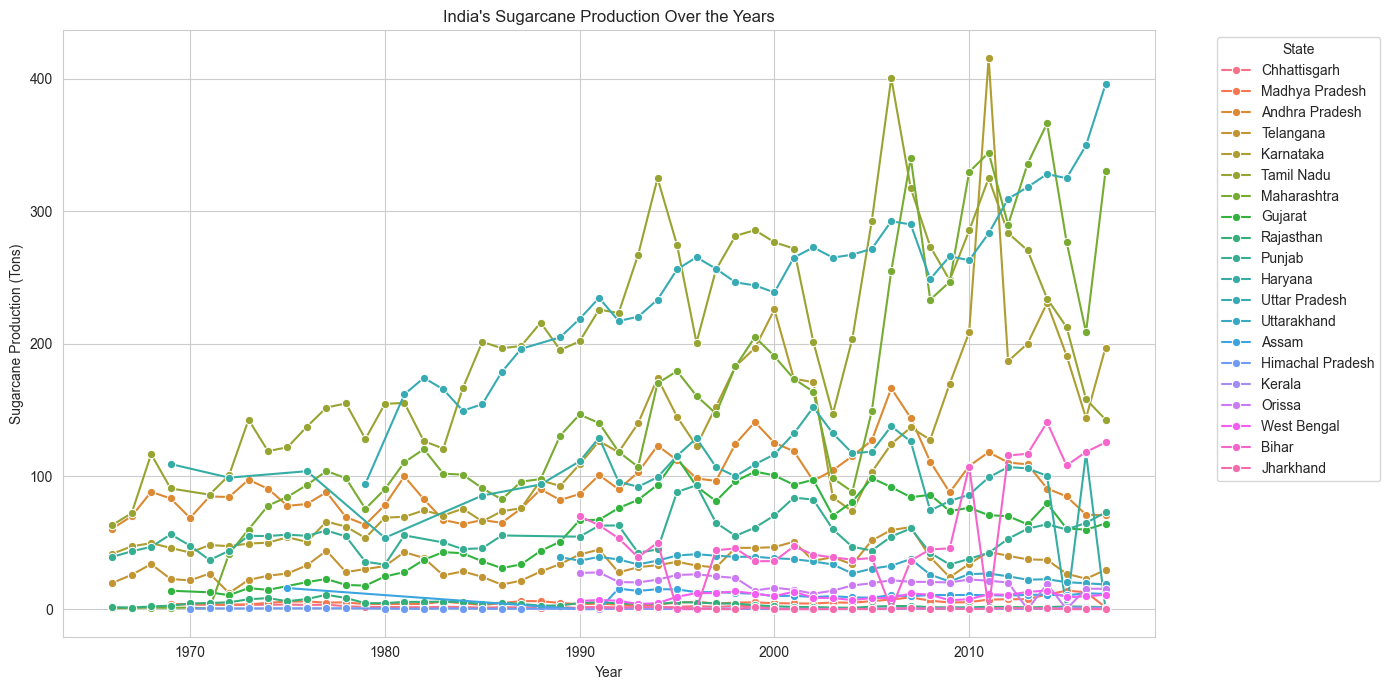

In [34]:
# India's Sugarcane production over the years (line plot)
plt.figure(figsize=(14, 7))
# use the standardized column names present in df
sns.lineplot(data=df, x='year', y='sugarcane_production_tons', hue='state_name', marker='o', err_style=None)
plt.title("India's Sugarcane Production Over the Years")
plt.xlabel('Year')
plt.ylabel('Sugarcane Production (Tons)')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

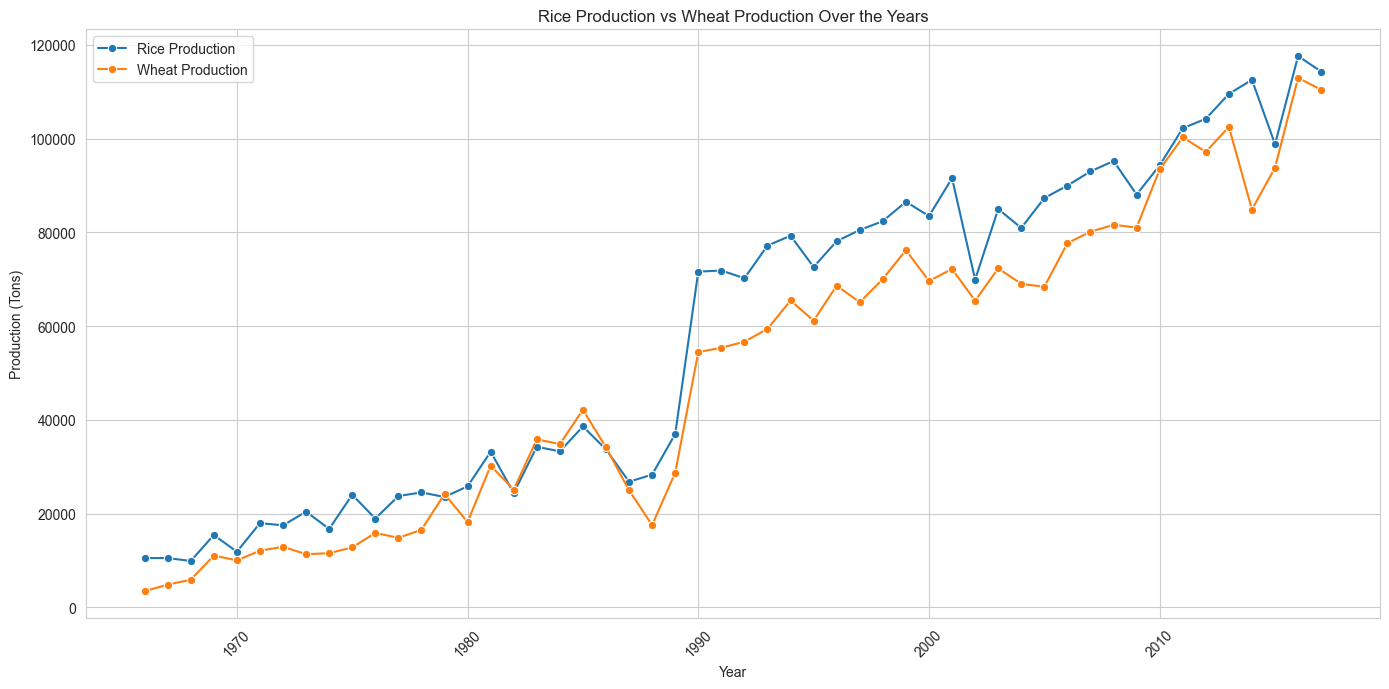

In [36]:
#Rice Production Vs Wheat Production (Last 50y)
plt.figure(figsize=(14, 7))
# aggregate production by year (use standardized column names)
yearly = df.groupby('year')[['rice_production_tons', 'wheat_production_tons']].sum().reset_index()
sns.lineplot(data=yearly, x='year', y='rice_production_tons', label='Rice Production', marker='o')
sns.lineplot(data=yearly, x='year', y='wheat_production_tons', label='Wheat Production', marker='o')
plt.title('Rice Production vs Wheat Production Over the Years')
plt.xlabel('Year')
plt.ylabel('Production (Tons)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\77400964.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='dist_name', y='rice_production_tons', data=wb_rice_production, palette='viridis')


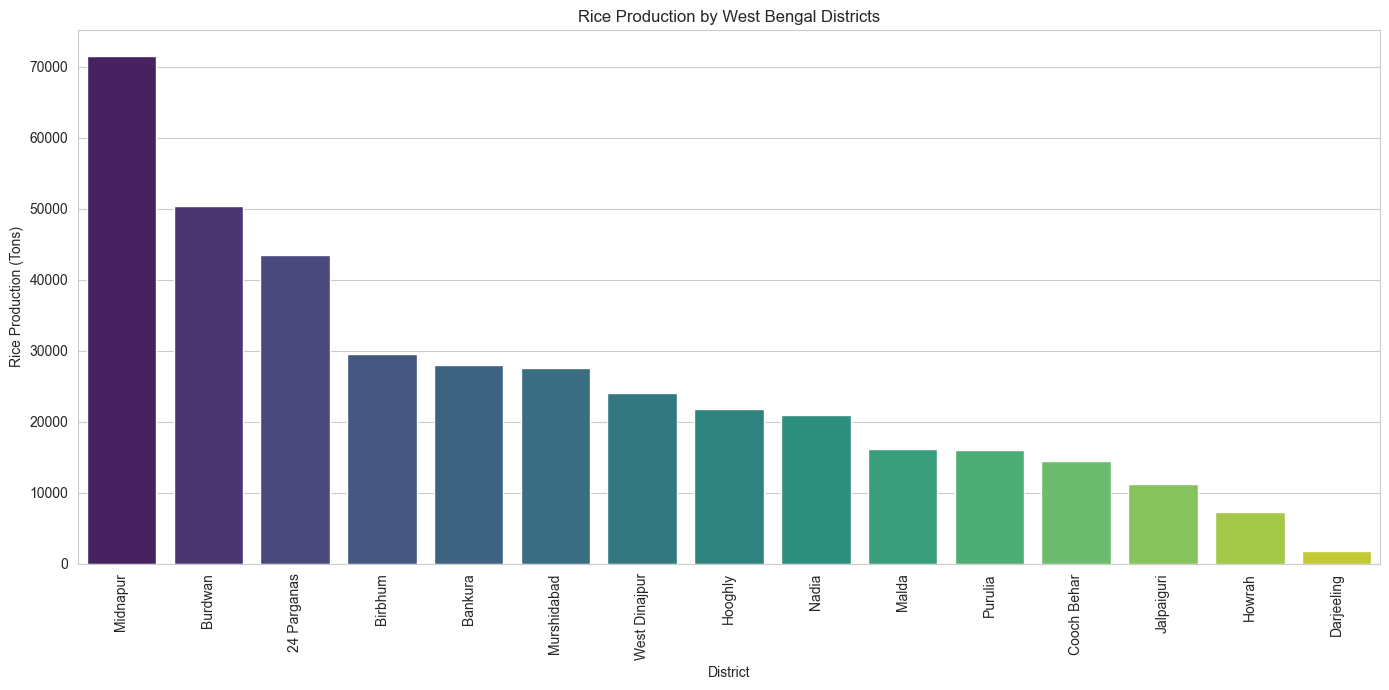

In [38]:
# Rice Production By West Bengal Districts
plt.figure(figsize=(14, 7))
# use standardized column names present in df: state_name, dist_name, rice_production_tons
wb_rice_production = (
	df[df['state_name'] == 'West Bengal']
	.groupby('dist_name', as_index=False)['rice_production_tons']
	.sum()
	.sort_values('rice_production_tons', ascending=False)
)
sns.barplot(x='dist_name', y='rice_production_tons', data=wb_rice_production, palette='viridis')
plt.xticks(rotation=90)
plt.title('Rice Production by West Bengal Districts')
plt.xlabel('District')
plt.ylabel('Rice Production (Tons)')
plt.tight_layout()
plt.show()

C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\2565487735.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='year', y='wheat_production_tons', data=top_up_wheat_years, palette='viridis')


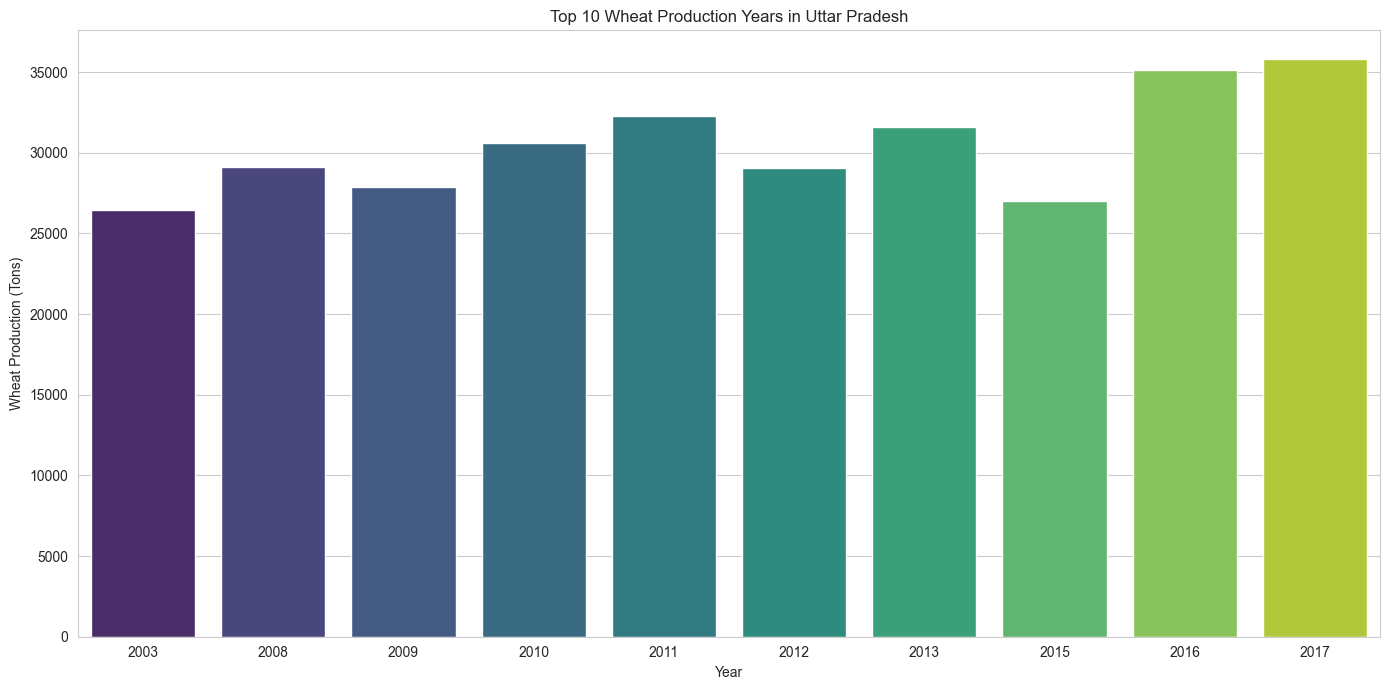

In [39]:
# Top 10 Wheat Production Years From Uttar Pradesh (using standardized column names)

plt.figure(figsize=(14, 7))
# use standardized column names present in df
up_wheat_production = (
	df[df['state_name'] == 'Uttar Pradesh']
	.groupby('year', as_index=False)['wheat_production_tons']
	.sum()
)
top_up_wheat_years = up_wheat_production.nlargest(10, 'wheat_production_tons')
sns.barplot(x='year', y='wheat_production_tons', data=top_up_wheat_years, palette='viridis')
plt.title('Top 10 Wheat Production Years in Uttar Pradesh')
plt.xlabel('Year')
plt.ylabel('Wheat Production (Tons)')
plt.tight_layout()
plt.show()

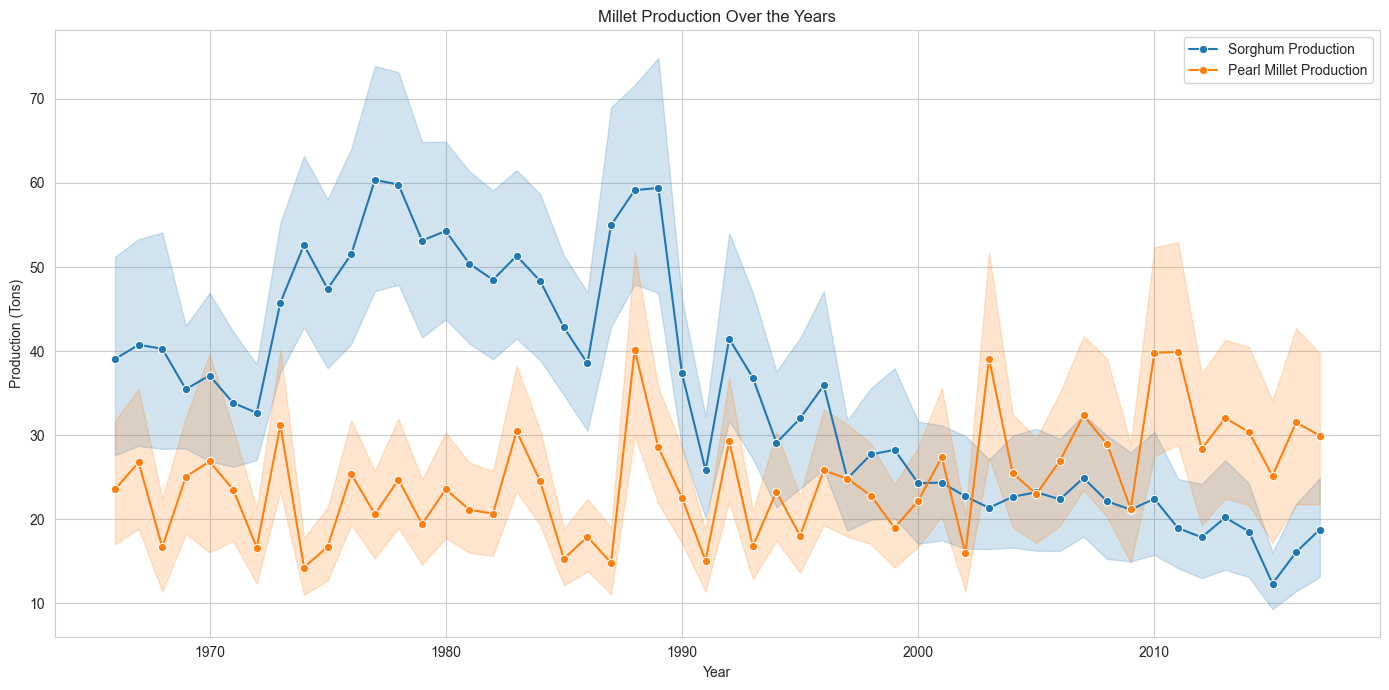

In [40]:
#Millet Production (Last 50y)
plt.figure(figsize=(14, 7))
# use the standardized column names present in df
sns.lineplot(data=df, x='year', y='sorghum_production_tons', label='Sorghum Production', marker='o')
sns.lineplot(data=df, x='year', y='pearl_millet_production_tons', label='Pearl Millet Production', marker='o')
plt.title('Millet Production Over the Years')
plt.xlabel('Year')
plt.ylabel('Production (Tons)')
plt.legend()
plt.tight_layout()
plt.show()

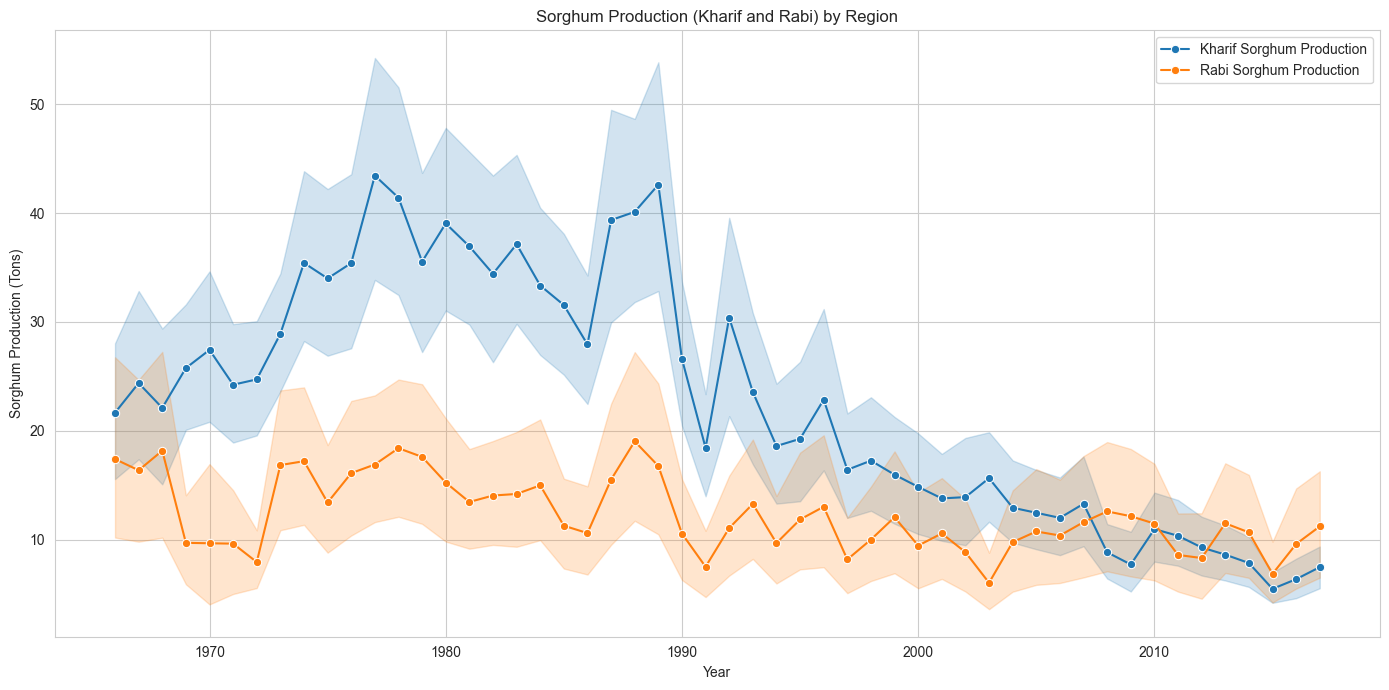

In [42]:
#Sorghum Production (Kharif and Rabi) by Region
plt.figure(figsize=(14, 7))
sns.lineplot(data=df, x='year', y='kharif_sorghum_production_tons', label='Kharif Sorghum Production', marker='o')
sns.lineplot(data=df, x='year', y='rabi_sorghum_production_tons', label='Rabi Sorghum Production', marker='o')
plt.title('Sorghum Production (Kharif and Rabi) by Region') 
plt.xlabel('Year')
plt.ylabel('Sorghum Production (Tons)')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\3369143035.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state_name', y='groundnut_production_tons', data=top_groundnut_states, palette='viridis')


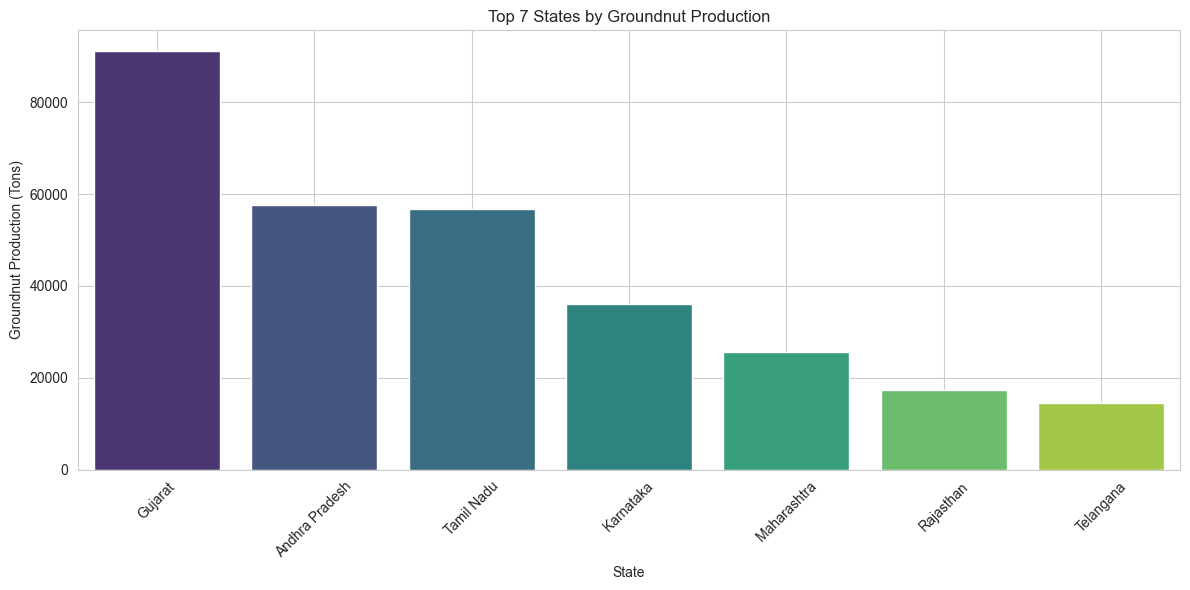

In [43]:
# Top 7 States for Groundnut Production
plt.figure(figsize=(12, 6))
# Use standardized column names present in df: 'state_name' and 'groundnut_production_tons'
top_groundnut_states = df.groupby('state_name')['groundnut_production_tons'].sum().nlargest(7).reset_index()
sns.barplot(x='state_name', y='groundnut_production_tons', data=top_groundnut_states, palette='viridis')
plt.xticks(rotation=45)
plt.grid(axis='x')
plt.title('Top 7 States by Groundnut Production')
plt.xlabel('State')
plt.ylabel('Groundnut Production (Tons)')
plt.tight_layout()
plt.show()

C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\900238690.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state_name', y='soyabean_production_tons', data=top_soybean_states, palette='viridis')


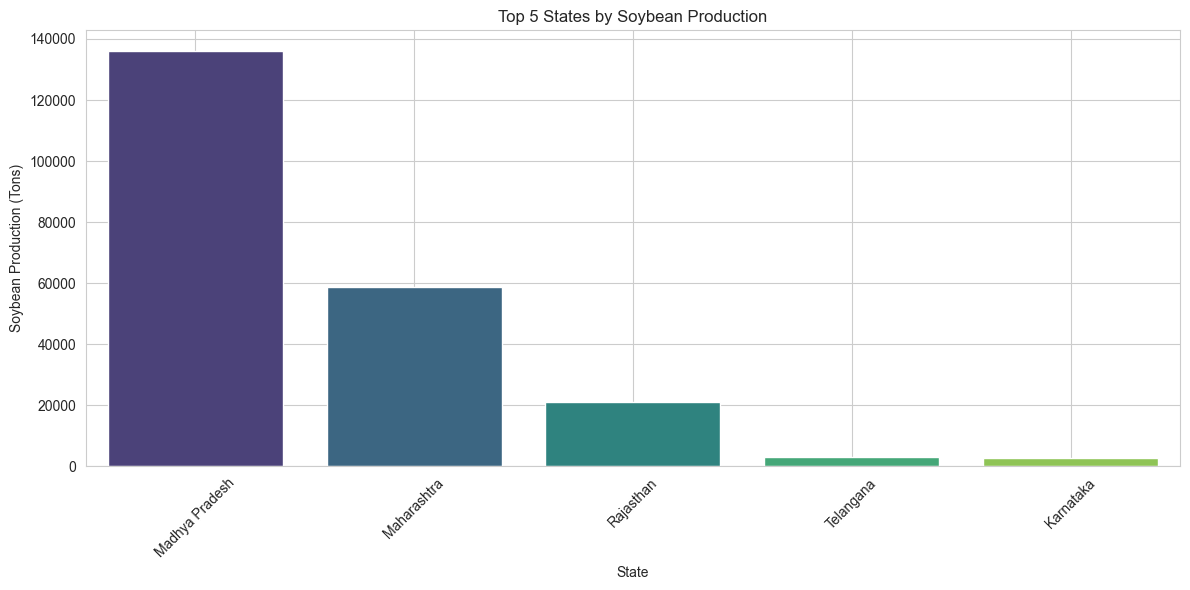

In [44]:
#Soybean Production by Top 5 States and Yield Efficiency
plt.figure(figsize=(12, 6))
top_soybean_states = df.groupby('state_name')['soyabean_production_tons'].sum().nlargest(5).reset_index()
sns.barplot(x='state_name', y='soyabean_production_tons', data=top_soybean_states, palette='viridis')
plt.xticks(rotation=45)
plt.grid(axis='x')
plt.title('Top 5 States by Soybean Production')
plt.xlabel('State')
plt.ylabel('Soybean Production (Tons)')
plt.tight_layout()
plt.show()

C:\Users\katlee\AppData\Local\Temp\ipykernel_11016\1483909998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='state_name', y='oilseeds_production_tons', data=top_oilseed_states, palette='viridis')


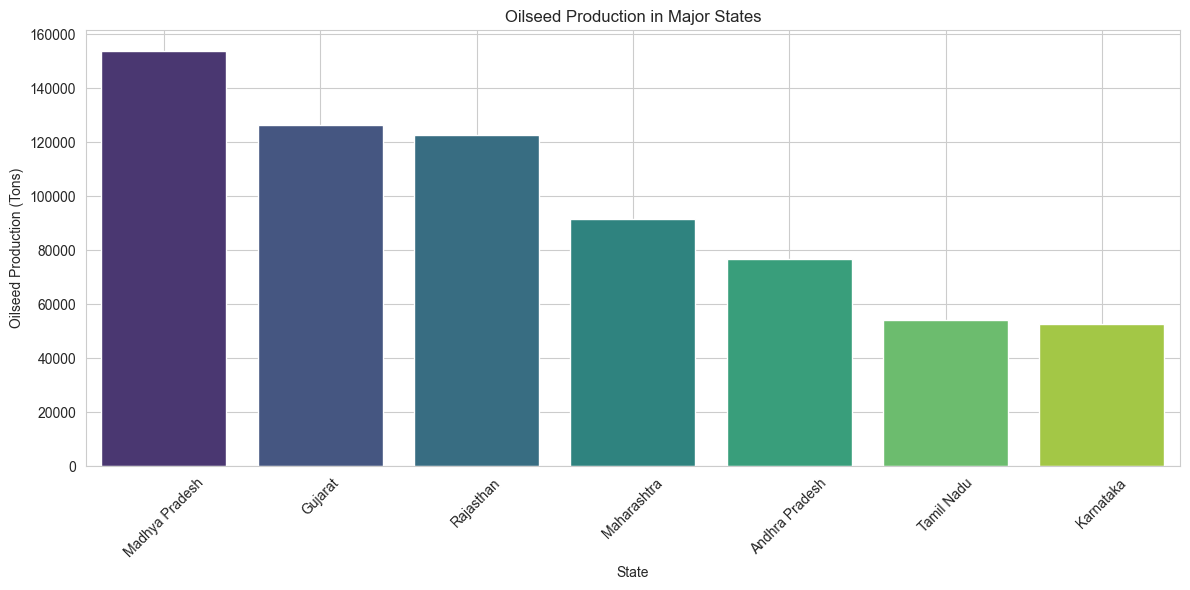

In [45]:
# Oilseed Production in Major States (use standardized column names already in df)
plt.figure(figsize=(12, 6))
top_oilseed_states = df.groupby('state_name')['oilseeds_production_tons'].sum().nlargest(7).reset_index()
sns.barplot(x='state_name', y='oilseeds_production_tons', data=top_oilseed_states, palette='viridis')
plt.grid(axis='x')
plt.xticks(rotation=45)
plt.title('Oilseed Production in Major States')
plt.xlabel('State')
plt.ylabel('Oilseed Production (Tons)')
plt.tight_layout()
plt.show()

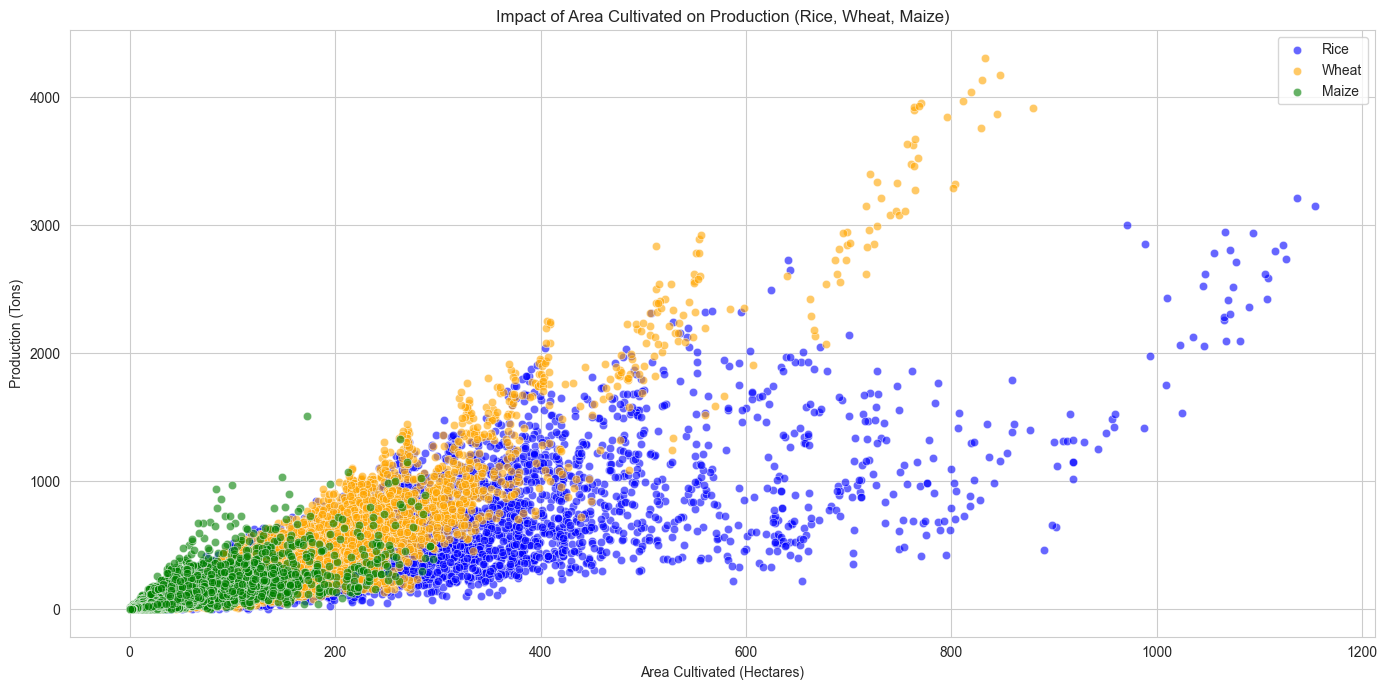

In [46]:
# Impact of Area Cultivated on Production (Rice, Wheat, Maize)
plt.figure(figsize=(14, 7))

# use standardized column names present in df
sns.scatterplot(data=df, x='rice_area_ha', y='rice_production_tons', label='Rice', color='blue', alpha=0.6)
sns.scatterplot(data=df, x='wheat_area_ha', y='wheat_production_tons', label='Wheat', color='orange', alpha=0.6)
sns.scatterplot(data=df, x='maize_area_ha', y='maize_production_tons', label='Maize', color='green', alpha=0.6)

plt.title('Impact of Area Cultivated on Production (Rice, Wheat, Maize)')
plt.xlabel('Area Cultivated (Hectares)')
plt.ylabel('Production (Tons)')
plt.legend()
plt.tight_layout()
plt.show()

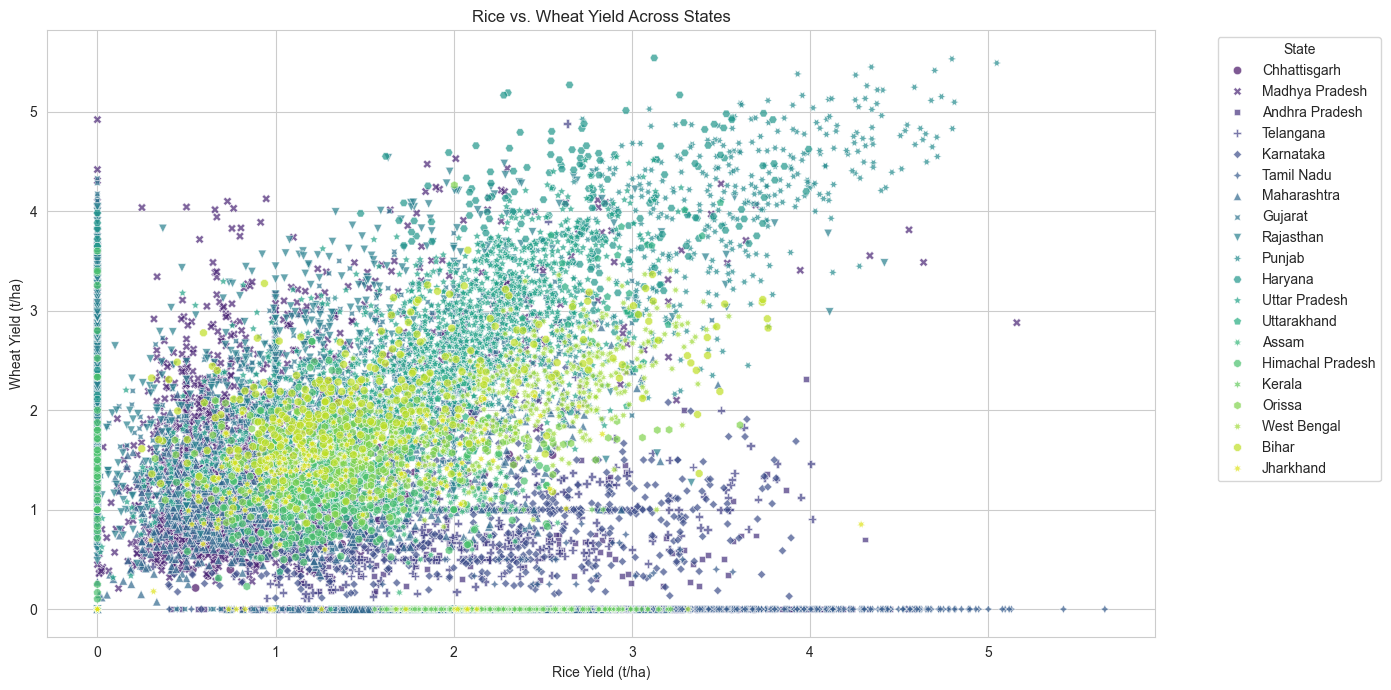

In [47]:
# Rice vs. Wheat Yield Across States (use correct column names and convert to t/ha)
plt.figure(figsize=(14, 7))
# convert kg/ha -> t/ha for plotting (columns in df are rice_yield_kg_ha and wheat_yield_kg_ha)
plot_df = df.assign(
	rice_yield_t_ha = df['rice_yield_kg_ha'] / 1000.0,
	wheat_yield_t_ha = df['wheat_yield_kg_ha'] / 1000.0
)

sns.scatterplot(
	data=plot_df,
	x='rice_yield_t_ha',
	y='wheat_yield_t_ha',
	hue='state_name',
	style='state_name',
	palette='viridis',
	alpha=0.7
)

plt.title('Rice vs. Wheat Yield Across States')
plt.xlabel('Rice Yield (t/ha)')
plt.ylabel('Wheat Yield (t/ha)')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [65]:
df.columns

Index(['dist_code', 'year', 'state_code', 'state_name', 'dist_name',
       'rice_area_ha', 'rice_production_tons', 'rice_yield_kg_ha',
       'wheat_area_ha', 'wheat_production_tons',
       ...
       'sesamum_yield_flag', 'rapeseed_and_mustard_yield_flag',
       'safflower_yield_flag', 'castor_yield_flag', 'linseed_yield_flag',
       'sunflower_yield_flag', 'soyabean_yield_flag', 'oilseeds_yield_flag',
       'sugarcane_yield_flag', 'cotton_yield_flag'],
      dtype='object', length=172)

postregers

In [48]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="2929",
    port="5432"
)

cursor = conn.cursor()

cursor.execute("SELECT version();")
db_version = cursor.fetchone()

print("PostgreSQL Version:", db_version)

cursor.close()
conn.close()


PostgreSQL Version: ('PostgreSQL 14.20, compiled by Visual C++ build 1944, 64-bit',)


In [50]:
connection = psycopg2.connect(
    host="localhost",
    database="postgres",
    user="postgres",
    password="2929",
    port="5432"
)
connection.set_isolation_level(ISOLATION_LEVEL_AUTOCOMMIT)
mediator = connection.cursor()

In [51]:

# check whether the database exists first to avoid DuplicateDatabase error
mediator.execute("SELECT 1 FROM pg_database WHERE datname = %s", ("postgres",))
exists = mediator.fetchone()
if not exists:
    mediator.execute("CREATE DATABASE postgres")
else:
    print("Database 'postgres' already exists. Skipping creation.")

mediator.close()
connection.close()

Database 'postgres' already exists. Skipping creation.


In [70]:
import psycopg2

connection = psycopg2.connect(
    host="localhost",
    database="postgres", 
    user="postgres",
    password="2929",
    port=5432
)

mediator = connection.cursor()

# ✅ 1. DROP the old broken table
drop_query = "DROP TABLE IF EXISTS dist_agri;"
mediator.execute(drop_query)

# ✅ 2. RE-CREATE table with FULL correct structure
create_table_query = """
CREATE TABLE dist_agri (
    id SERIAL PRIMARY KEY,

    district_code VARCHAR(100), 
    year INTEGER,
    state_code VARCHAR(100),
    state VARCHAR(100),
    district VARCHAR(100),

    rice_area FLOAT,
    rice_production FLOAT,
    rice_yield FLOAT,

    wheat_area FLOAT,
    wheat_production FLOAT,
    wheat_yield FLOAT,

    kharif_sorghum_area FLOAT,
    kharif_sorghum_production FLOAT,
    kharif_sorghum_yield FLOAT,

    rabi_sorghum_area FLOAT,
    rabi_sorghum_production FLOAT,
    rabi_sorghum_yield FLOAT,

    sorghum_area FLOAT,
    sorghum_production FLOAT,
    sorghum_yield FLOAT,

    pearl_millet_area FLOAT,
    pearl_millet_production FLOAT,
    pearl_millet_yield FLOAT,

    maize_area FLOAT,
    maize_production FLOAT,
    maize_yield FLOAT,

    finger_millet_area FLOAT,
    finger_millet_production FLOAT,
    finger_millet_yield FLOAT,

    barley_area FLOAT,
    barley_production FLOAT,
    barley_yield FLOAT,

    chickpea_area FLOAT,
    chickpea_production FLOAT,
    chickpea_yield FLOAT,

    pigeonpea_area FLOAT,
    pigeonpea_production FLOAT,
    pigeonpea_yield FLOAT,

    minor_pulses_area FLOAT,
    minor_pulses_production FLOAT,
    minor_pulses_yield FLOAT,

    groundnut_area FLOAT,
    groundnut_production FLOAT,
    groundnut_yield FLOAT,

    sesamum_area FLOAT,
    sesamum_production FLOAT,
    sesamum_yield FLOAT,

    rapeseed_mustard_area FLOAT,
    rapeseed_mustard_production FLOAT,
    rapeseed_mustard_yield FLOAT,

    safflower_area FLOAT,
    safflower_production FLOAT,
    safflower_yield FLOAT,

    castor_area FLOAT,
    castor_production FLOAT,
    castor_yield FLOAT,

    linseed_area FLOAT,
    linseed_production FLOAT,
    linseed_yield FLOAT,

    sunflower_area FLOAT,
    sunflower_production FLOAT,
    sunflower_yield FLOAT,

    soyabean_area FLOAT,
    soyabean_production FLOAT,
    soyabean_yield FLOAT,

    oilseeds_area FLOAT,
    oilseeds_production FLOAT,
    oilseeds_yield FLOAT,

    sugarcane_area FLOAT,
    sugarcane_production FLOAT,
    sugarcane_yield FLOAT,

    cotton_area FLOAT,
    cotton_production FLOAT,
    cotton_yield FLOAT,

    fruits_area FLOAT,
    vegetables_area FLOAT,
    fruits_vegetables_area FLOAT,
    potatoes_area FLOAT,
    onion_area FLOAT,
    fodder_area FLOAT
);
"""

mediator.execute(create_table_query)
connection.commit()

print("✅ dist_agri table DROPPED and RECREATED successfully")

mediator.close()
connection.close()


✅ dist_agri table DROPPED and RECREATED successfully


In [71]:
import psycopg2
import numpy as np

# ✅ INSERT QUERY
insert_query = """
INSERT INTO dist_agri (
    District_Code, Year, State_Code, State, District,
    rice_area, rice_production, rice_yield,
    wheat_area, wheat_production, wheat_yield,
    kharif_sorghum_area, kharif_sorghum_production, kharif_sorghum_yield,
    rabi_sorghum_area, rabi_sorghum_production, rabi_sorghum_yield,
    sorghum_area, sorghum_production, sorghum_yield,
    pearl_millet_area, pearl_millet_production, pearl_millet_yield,
    maize_area, maize_production, maize_yield,
    finger_millet_area, finger_millet_production, finger_millet_yield,
    barley_area, barley_production, barley_yield,
    chickpea_area, chickpea_production, chickpea_yield,
    pigeonpea_area, pigeonpea_production, pigeonpea_yield,
    minor_pulses_area, minor_pulses_production, minor_pulses_yield,
    groundnut_area, groundnut_production, groundnut_yield,
    sesamum_area, sesamum_production, sesamum_yield,
    rapeseed_mustard_area, rapeseed_mustard_production, rapeseed_mustard_yield,
    safflower_area, safflower_production, safflower_yield,
    castor_area, castor_production, castor_yield,
    linseed_area, linseed_production, linseed_yield,
    sunflower_area, sunflower_production, sunflower_yield,
    soyabean_area, soyabean_production, soyabean_yield,
    oilseeds_area, oilseeds_production, oilseeds_yield,
    sugarcane_area, sugarcane_production, sugarcane_yield,
    cotton_area, cotton_production, cotton_yield,
    fruits_area, vegetables_area, fruits_vegetables_area,
    potatoes_area, onion_area, fodder_area
) 
VALUES (
%s,%s,%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s,
%s,%s,%s
);
"""

# ✅ FIELD ORDER (MUST MATCH INSERT ORDER)
fields_order = [
    'dist_code','year','state_code','state_name','dist_name',
    'rice_area_ha','rice_production_tons','rice_yield_kg_ha',
    'wheat_area_ha','wheat_production_tons','wheat_yield_kg_ha',
    'kharif_sorghum_area_ha','kharif_sorghum_production_tons','kharif_sorghum_yield_kg_ha',
    'rabi_sorghum_area_ha','rabi_sorghum_production_tons','rabi_sorghum_yield_kg_ha',
    'sorghum_area_ha','sorghum_production_tons','sorghum_yield_kg_ha',
    'pearl_millet_area_ha','pearl_millet_production_tons','pearl_millet_yield_kg_ha',
    'maize_area_ha','maize_production_tons','maize_yield_kg_ha',
    'finger_millet_area_ha','finger_millet_production_tons','finger_millet_yield_kg_ha',
    'barley_area_ha','barley_production_tons','barley_yield_kg_ha',
    'chickpea_area_ha','chickpea_production_tons','chickpea_yield_kg_ha',
    'pigeonpea_area_ha','pigeonpea_production_tons','pigeonpea_yield_kg_ha',
    'minor_pulses_area_ha','minor_pulses_production_tons','minor_pulses_yield_kg_ha',
    'groundnut_area_ha','groundnut_production_tons','groundnut_yield_kg_ha',
    'sesamum_area_ha','sesamum_production_tons','sesamum_yield_kg_ha',
    'rapeseed_and_mustard_area_ha','rapeseed_and_mustard_production_tons','rapeseed_and_mustard_yield_kg_ha',
    'safflower_area_ha','safflower_production_tons','safflower_yield_kg_ha',
    'castor_area_ha','castor_production_tons','castor_yield_kg_ha',
    'linseed_area_ha','linseed_production_tons','linseed_yield_kg_ha',
    'sunflower_area_ha','sunflower_production_tons','sunflower_yield_kg_ha',
    'soyabean_area_ha','soyabean_production_tons','soyabean_yield_kg_ha',
    'oilseeds_area_ha','oilseeds_production_tons','oilseeds_yield_kg_ha',
    'sugarcane_area_ha','sugarcane_production_tons','sugarcane_yield_kg_ha',
    'cotton_area_ha','cotton_production_tons','cotton_yield_kg_ha',
    'fruits_area_ha','vegetables_area_ha','fruits_and_vegetables_area_ha',
    'potatoes_area_ha','onion_area_ha','fodder_area_ha'
]

# ✅ CREATE MISSING DF COLUMNS IF ANY
missing = [f for f in fields_order if f not in df.columns]
if missing:
    print("Creating missing DataFrame columns (filled with NaN):", missing)
    for m in missing:
        df[m] = np.nan

# ✅ BUILD DATA TUPLES
data_to_insert = [tuple(row[f] for f in fields_order) for _, row in df.iterrows()]

# ✅ INSERT INTO POSTGRESQL
connection = None
mediator = None

try:
    connection = psycopg2.connect(
        host="localhost",
        user="postgres",
        password="2929",
        port=5432,
        dbname="postgres"
    )

    mediator = connection.cursor()

    # ✅ SAFETY CHECK
    placeholder_count = insert_query.count('%s')
    first_len = len(data_to_insert[0]) if data_to_insert else 0

    if placeholder_count != first_len:
        raise RuntimeError(
            f"Placeholders ({placeholder_count}) != tuple size ({first_len})"
        )

    mediator.executemany(insert_query, data_to_insert)
    connection.commit()

    print("✅ Data inserted successfully into dist_agri table.")

except Exception as e:
    print("❌ Error while inserting data:", e)

finally:
    if mediator:
        mediator.close()
    if connection:
        connection.close()
        print("✅ PostgreSQL connection is closed.")


✅ Data inserted successfully into dist_agri table.
✅ PostgreSQL connection is closed.


In [73]:
# Quick checks for the prepared insertion tuples
print('Rows in df:', len(df))
print('Number of tuples prepared:', len(data_to_insert))

# NaN counts for fields used in insertion (helps spot missing data)
nan_counts = df[fields_order].isna().sum()
print('\nNaN counts for insert fields:')
print(nan_counts)

print('\nData types for fields used in insertion:')
print(df[fields_order].dtypes)

print('\nFirst 3 rows (fields used for insert):')
display(df[fields_order].head(10))

print('\nFirst 3 tuples to insert (showing only first 8 values per tuple to keep it short):')
for t in data_to_insert[:3]:
    print(len(t), t[:8])

Rows in df: 13092
Number of tuples prepared: 13092

NaN counts for insert fields:
dist_code                        0
year                             0
state_code                       0
state_name                       0
dist_name                        0
                                ..
vegetables_area_ha               0
fruits_and_vegetables_area_ha    0
potatoes_area_ha                 0
onion_area_ha                    0
fodder_area_ha                   0
Length: 80, dtype: int64

Data types for fields used in insertion:
dist_code                          int64
year                               int64
state_code                         int64
state_name                        object
dist_name                         object
                                  ...   
vegetables_area_ha               float64
fruits_and_vegetables_area_ha    float64
potatoes_area_ha                 float64
onion_area_ha                    float64
fodder_area_ha                   float64
Length: 80, dty

,dist_code,year,state_code,state_name,dist_name,rice_area_ha,rice_production_tons,rice_yield_kg_ha,wheat_area_ha,wheat_production_tons,...,sugarcane_yield_kg_ha,cotton_area_ha,cotton_production_tons,cotton_yield_kg_ha,fruits_area_ha,vegetables_area_ha,fruits_and_vegetables_area_ha,potatoes_area_ha,onion_area_ha,fodder_area_ha
3,1,1969,14,Chhattisgarh,Durg,563.4,400.8,711.40,49.4,26.5,...,1900.00,0.0,0.0,0.0,5.52,7.16,12.69,0.01,0.56,0.84
4,1,1970,14,Chhattisgarh,Durg,571.6,473.6,828.55,44.2,29.0,...,2000.00,0.0,0.0,0.0,5.45,7.19,12.64,0.02,0.52,0.42
5,1,1971,14,Chhattisgarh,Durg,581.8,412.9,709.69,44.4,25.8,...,2000.00,0.0,0.0,0.0,5.42,7.48,12.91,0.01,0.54,0.38
6,1,1972,14,Chhattisgarh,Durg,582.2,381.0,654.41,39.6,20.6,...,2000.00,0.0,0.0,0.0,5.48,7.53,13.01,0.01,0.55,0.26
7,1,1973,14,Chhattisgarh,Durg,600.0,471.9,786.50,37.3,18.6,...,6000.00,0.0,0.0,0.0,5.30,7.60,12.90,0.01,0.53,0.14
8,1,1974,14,Chhattisgarh,Durg,587.4,219.0,372.83,36.5,22.4,...,1875.00,0.0,0.0,0.0,5.21,7.44,12.64,0.03,0.45,0.06
9,1,1975,14,Chhattisgarh,Durg,598.3,454.0,758.82,49.2,27.8,...,1750.00,0.0,0.0,0.0,5.11,7.86,12.97,0.05,0.52,0.08
10,1,1976,14,Chhattisgarh,Durg,593.6,327.1,551.04,46.9,10.0,...,1333.33,0.0,0.0,0.0,4.90,7.86,12.76,0.06,0.46,0.07
11,1,1977,14,Chhattisgarh,Durg,600.7,572.4,952.89,53.1,27.1,...,3000.00,0.0,0.0,0.0,4.98,8.45,13.43,0.05,0.53,0.32
12,1,1978,14,Chhattisgarh,Durg,612.5,362.2,591.35,48.7,25.6,...,2000.00,0.0,0.0,0.0,4.75,8.67,13.41,0.04,0.43,0.34



First 3 tuples to insert (showing only first 8 values per tuple to keep it short):
80 (1, 1969, 14, 'Chhattisgarh', 'Durg', 563.4, 400.8, 711.4)
80 (1, 1970, 14, 'Chhattisgarh', 'Durg', 571.6, 473.6, 828.55)
80 (1, 1971, 14, 'Chhattisgarh', 'Durg', 581.8, 412.9, 709.69)
